In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
import warnings
warnings.filterwarnings('ignore')

sns.set_theme(style="whitegrid", palette="muted")
print("Libraries loaded successfully!")

Libraries loaded successfully!


In [2]:
df = pd.read_csv('../data/raw/ai4i2020.csv')

print("Shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nNull Values:\n", df.isnull().sum())
print("\nTarget Distribution:\n", df['Machine failure'].value_counts())

Shape: (10000, 14)

Columns: ['UDI', 'Product ID', 'Type', 'Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]', 'Machine failure', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF']

Null Values:
 UDI                        0
Product ID                 0
Type                       0
Air temperature [K]        0
Process temperature [K]    0
Rotational speed [rpm]     0
Torque [Nm]                0
Tool wear [min]            0
Machine failure            0
TWF                        0
HDF                        0
PWF                        0
OSF                        0
RNF                        0
dtype: int64

Target Distribution:
 Machine failure
0    9661
1     339
Name: count, dtype: int64


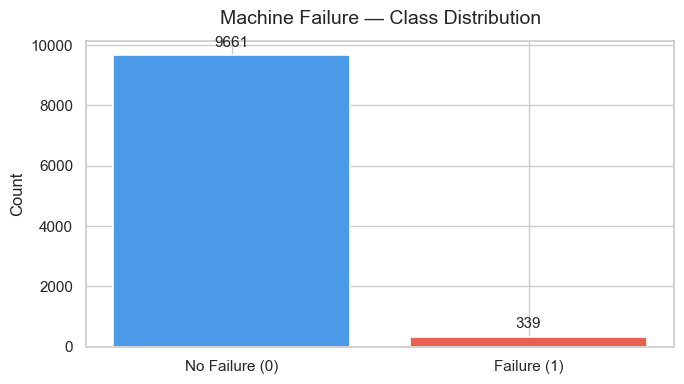

Imbalance ratio: 28.5:1


In [3]:
import os
os.makedirs('../reports/figures', exist_ok=True)

fig, ax = plt.subplots(figsize=(7, 4))
counts = df['Machine failure'].value_counts()
bars = ax.bar(['No Failure (0)', 'Failure (1)'],
               counts.values,
               color=['#4C9BE8', '#E8614C'],
               edgecolor='white', linewidth=1.2)
ax.bar_label(bars, fmt='%d', padding=4, fontsize=11)
ax.set_title('Machine Failure — Class Distribution', fontsize=14, pad=12)
ax.set_ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/01_class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()
print(f"Imbalance ratio: {counts[0]/counts[1]:.1f}:1")

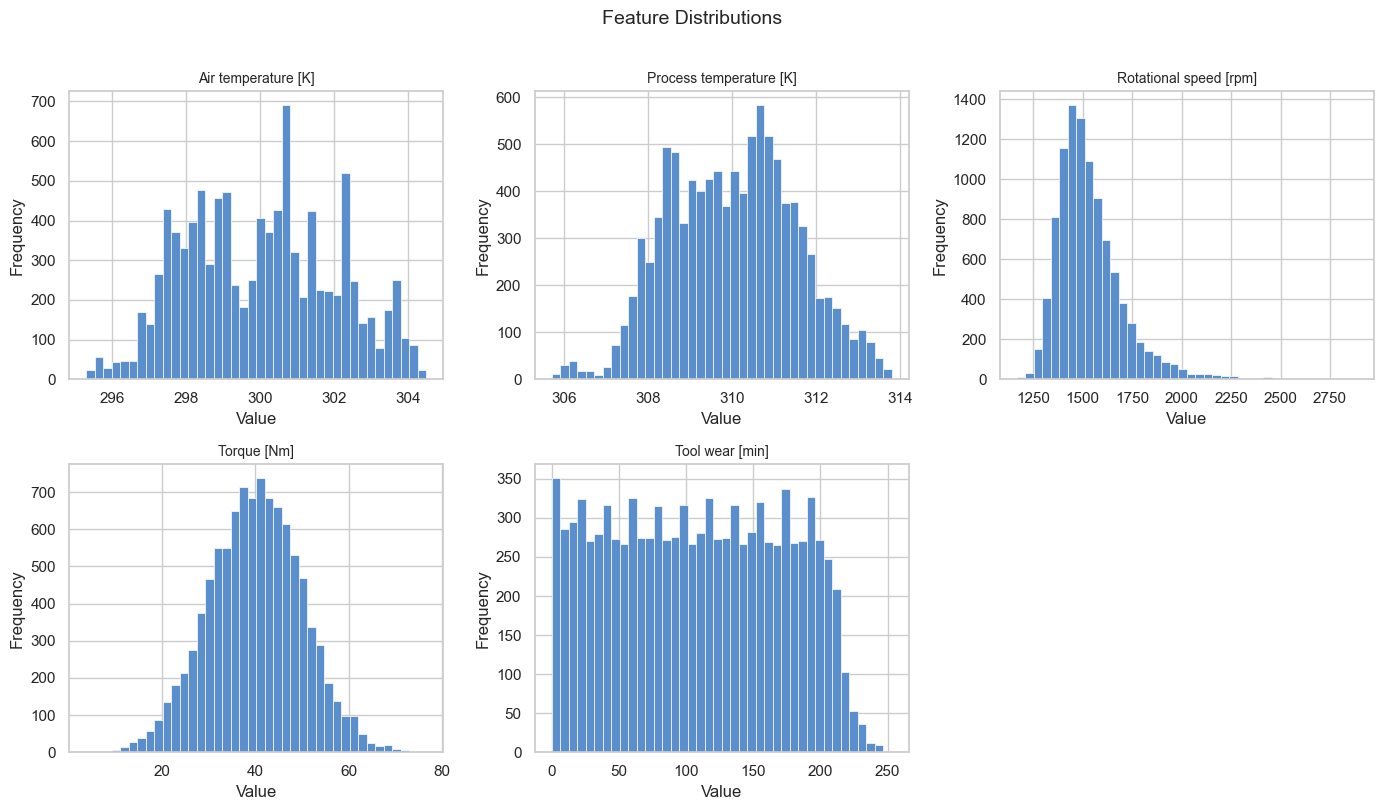

In [4]:
numeric_cols = ['Air temperature [K]', 'Process temperature [K]',
                'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, col in enumerate(numeric_cols):
    axes[i].hist(df[col], bins=40, color='#5B8ECC', edgecolor='white', linewidth=0.5)
    axes[i].set_title(col, fontsize=10)
    axes[i].set_xlabel('Value')
    axes[i].set_ylabel('Frequency')

axes[5].set_visible(False)
fig.suptitle('Feature Distributions', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig('../reports/figures/02_feature_distributions.png', dpi=150, bbox_inches='tight')
plt.show()

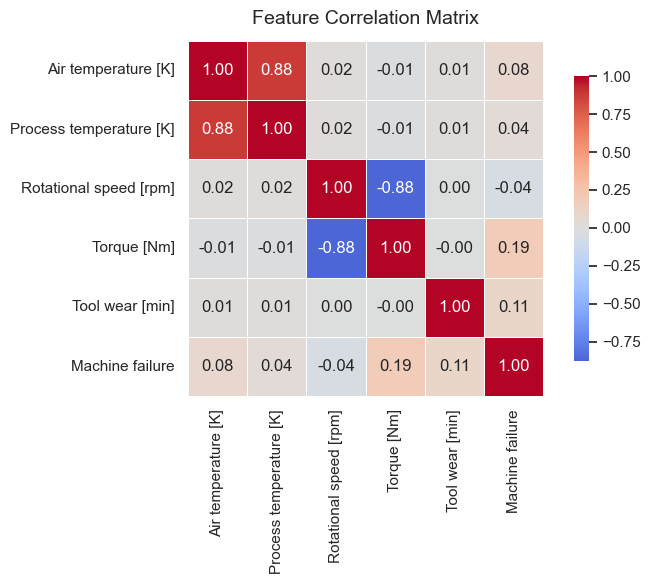

In [5]:
corr_cols = ['Air temperature [K]', 'Process temperature [K]',
             'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]',
             'Machine failure']
corr = df[corr_cols].corr()

fig, ax = plt.subplots(figsize=(8, 6))
sns.heatmap(corr,
            annot=True, fmt='.2f',
            cmap='coolwarm', center=0,
            linewidths=0.5, linecolor='white',
            square=True, ax=ax,
            cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Matrix', fontsize=14, pad=12)
plt.tight_layout()
plt.savefig('../reports/figures/03_correlation_heatmap.png', dpi=150, bbox_inches='tight')
plt.show()

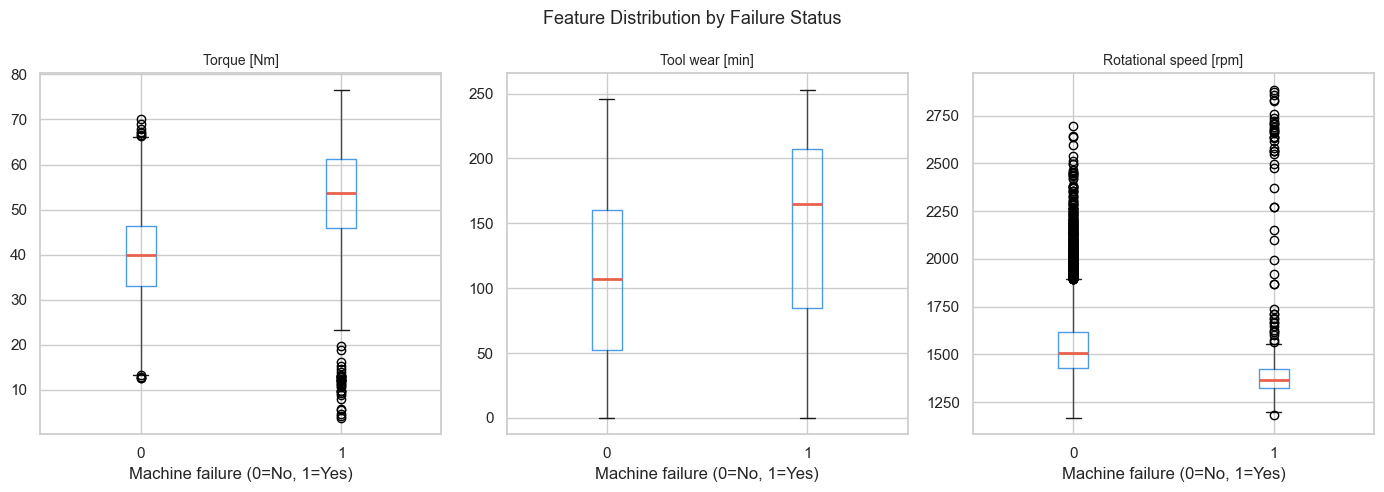

In [6]:
fig, axes = plt.subplots(1, 3, figsize=(14, 5))
features_to_check = ['Torque [Nm]', 'Tool wear [min]', 'Rotational speed [rpm]']

for ax, feat in zip(axes, features_to_check):
    df.boxplot(column=feat, by='Machine failure', ax=ax,
               boxprops=dict(color='#4C9BE8'),
               medianprops=dict(color='#E8614C', linewidth=2))
    ax.set_title(feat, fontsize=10)
    ax.set_xlabel('Machine failure (0=No, 1=Yes)')

fig.suptitle('Feature Distribution by Failure Status', fontsize=13)
plt.tight_layout()
plt.savefig('../reports/figures/04_features_by_failure.png', dpi=150, bbox_inches='tight')
plt.show()

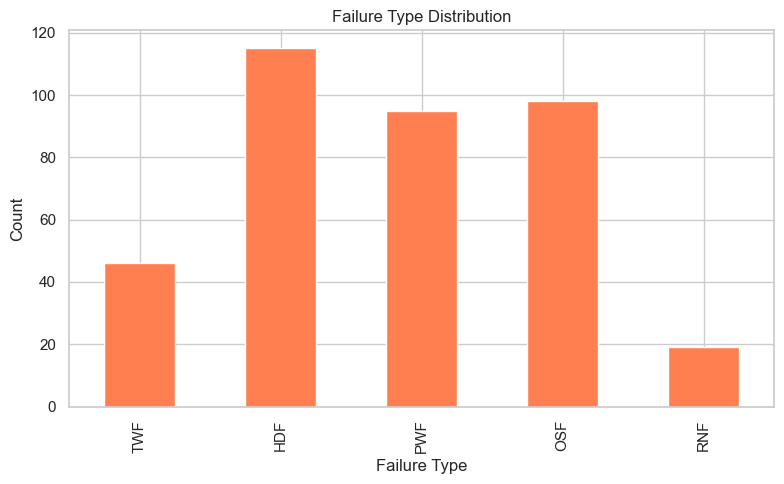

TWF     46
HDF    115
PWF     95
OSF     98
RNF     19
dtype: int64


In [7]:
# Failure type analysis
failure_cols = ['TWF', 'HDF', 'PWF', 'OSF', 'RNF']
failure_counts = df[failure_cols].sum()
plt.figure(figsize=(8,5))
failure_counts.plot(kind='bar', color='coral')
plt.title('Failure Type Distribution')
plt.xlabel('Failure Type')
plt.ylabel('Count')
plt.tight_layout()
plt.savefig('../reports/figures/05_failure_types.png')
plt.show()
print(failure_counts)